# Multimodal Clustering Experiment with Gemini Embeddings
In this notebook, I try to explore the similarities **between different data entries** by generating a single combined embedding for each entry (using both its image and caption simultaneously) via the Gemini API. We analyze the first 10 entries of the `tokyo_first100_local_ok.csv` dataset. Note: Please add your API key below manually.

In [12]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image

# Gemini SDK (NEW)
from google import genai

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

In [13]:
# Load dataset (first 10 rows for testing)
dataset_path = r"c:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Other\Dataset\tokyo_first100_local_ok.csv"

df = pd.read_csv(dataset_path).tail(20)

display(df[['photo/video_page_url', 'caption']])

,photo/video_page_url,caption
139,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Feeling sad and missing home.
140,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Hopeful after a small win.
141,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,"A little anxious, but still hopeful."
142,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Hopeful after a small win.
143,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Today felt peaceful and steady.
144,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,"I’m stressed, but trying to breathe through it."
145,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Hopeful after a small win.
146,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,"Drained, but proud I made it through."
147,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,Feeling overwhelmed and tired.
148,C:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\Oth...,I’m proud of myself for showing up.


In [ ]:
# Configure Gemini API
API_KEY = ''
client = genai.Client(api_key=API_KEY)

print("Gemini client initialized successfully")

Gemini client initialized successfully


In [15]:
def get_combined_multimodal_embedding(image_path, text):
    """
    Generates a SINGLE embedding using:
    image + caption together (multimodal)

    Returns a vector embedding.
    """

    try:
        img = Image.open(image_path)

        result = client.models.embed_content(
            model="models/gemini-embedding-2-preview",
            contents=[img, text]
        )

        embedding = result.embeddings[0].values
        return np.array(embedding)

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return None

In [16]:
combined_embeddings = []

print("Generating multimodal embeddings...")

for idx, row in df.iterrows():

    img_path = row['photo/video_page_url']
    caption = row['caption']

    embedding = get_combined_multimodal_embedding(img_path, caption)

    if embedding is not None:
        combined_embeddings.append(embedding)
    else:
        print(f"Skipping entry {idx}")

combined_embeddings = np.array(combined_embeddings)

print("Total embeddings generated:", len(combined_embeddings))

Generating multimodal embeddings...
Total embeddings generated: 20


In [17]:
# Compute cosine similarity between entries

similarity_matrix = cosine_similarity(
    combined_embeddings,
    combined_embeddings
)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (20, 20)


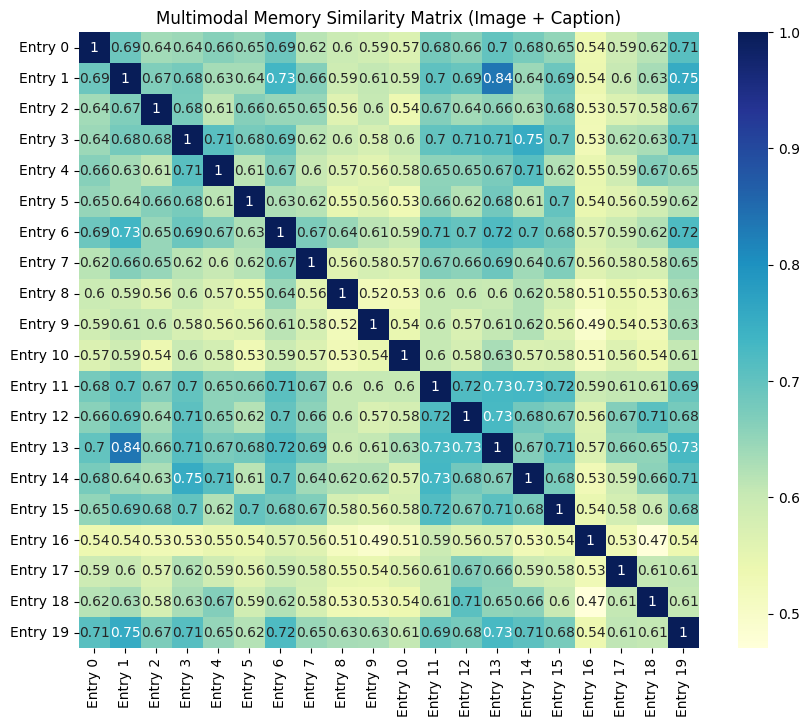

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="YlGnBu",
    xticklabels=[f"Entry {i}" for i in range(len(combined_embeddings))],
    yticklabels=[f"Entry {i}" for i in range(len(combined_embeddings))]
)

plt.title("Multimodal Memory Similarity Matrix (Image + Caption)")
plt.show()

In [19]:
# Show most similar memory pairs

pairs = []

n = len(similarity_matrix)

for i in range(n):
    for j in range(i+1, n):
        pairs.append((i, j, similarity_matrix[i][j]))

pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 5 most similar memories:\n")

for p in pairs[:5]:
    print(f"Entry {p[0]} ↔ Entry {p[1]}  | Similarity = {p[2]:.3f}")

Top 5 most similar memories:

Entry 1 ↔ Entry 13  | Similarity = 0.836
Entry 1 ↔ Entry 19  | Similarity = 0.754
Entry 3 ↔ Entry 14  | Similarity = 0.753
Entry 1 ↔ Entry 6  | Similarity = 0.734
Entry 11 ↔ Entry 14  | Similarity = 0.732


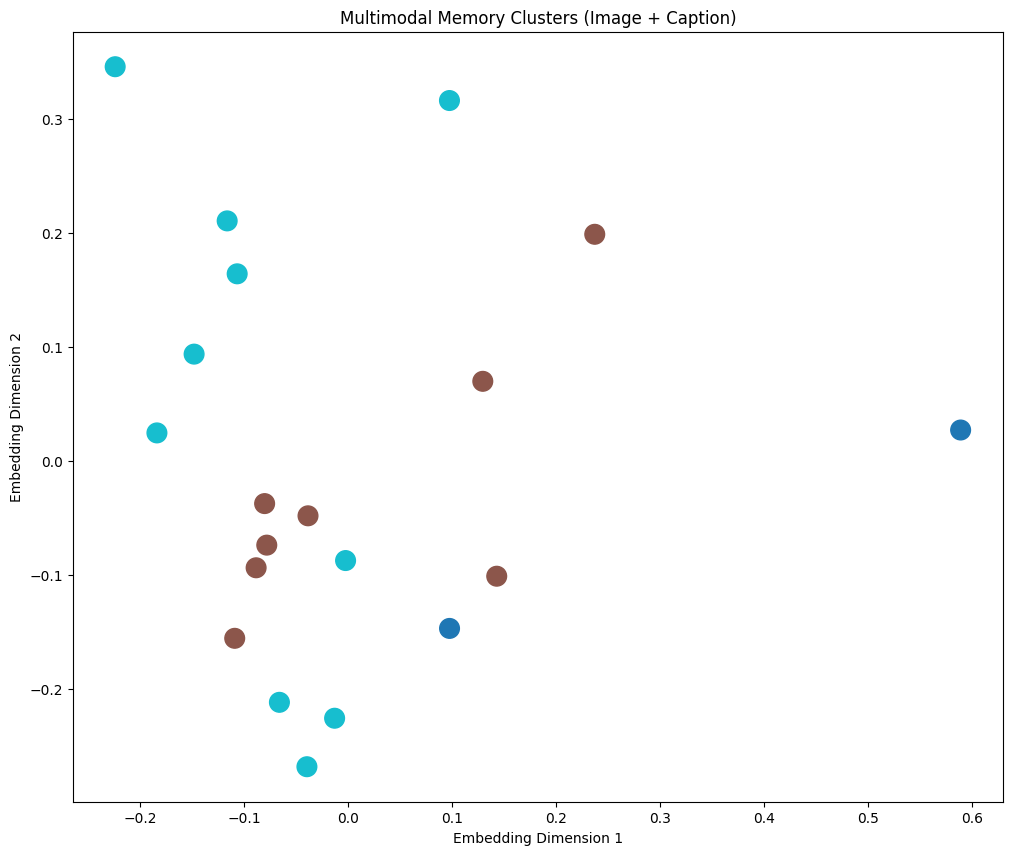

In [20]:
# --- Visualize clusters of memories (image + caption) ---

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Reduce embedding dimension to 2D for visualization
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(combined_embeddings)

# Choose number of clusters
num_clusters = 3
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(combined_embeddings)

# Plot
plt.figure(figsize=(12,10))
ax = plt.gca()

scatter = ax.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=clusters,
    cmap="tab10",
    s=200
)

# Add image thumbnails
for i, row in df.iloc[:len(embeddings_2d)].iterrows():

    try:
        img = Image.open(row['photo/video_page_url'])
        img.thumbnail((80,80))

        imagebox = OffsetImage(img, zoom=1)
        ab = AnnotationBbox(
            imagebox,
            (embeddings_2d[i][0], embeddings_2d[i][1]),
            frameon=False
        )

        ax.add_artist(ab)

        # add short caption
        caption = str(row['caption'])[:40] + "..."
        ax.text(
            embeddings_2d[i][0],
            embeddings_2d[i][1],
            caption,
            fontsize=8,
            ha='center',
            va='top'
        )

    except:
        continue


plt.title("Multimodal Memory Clusters (Image + Caption)")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.show()

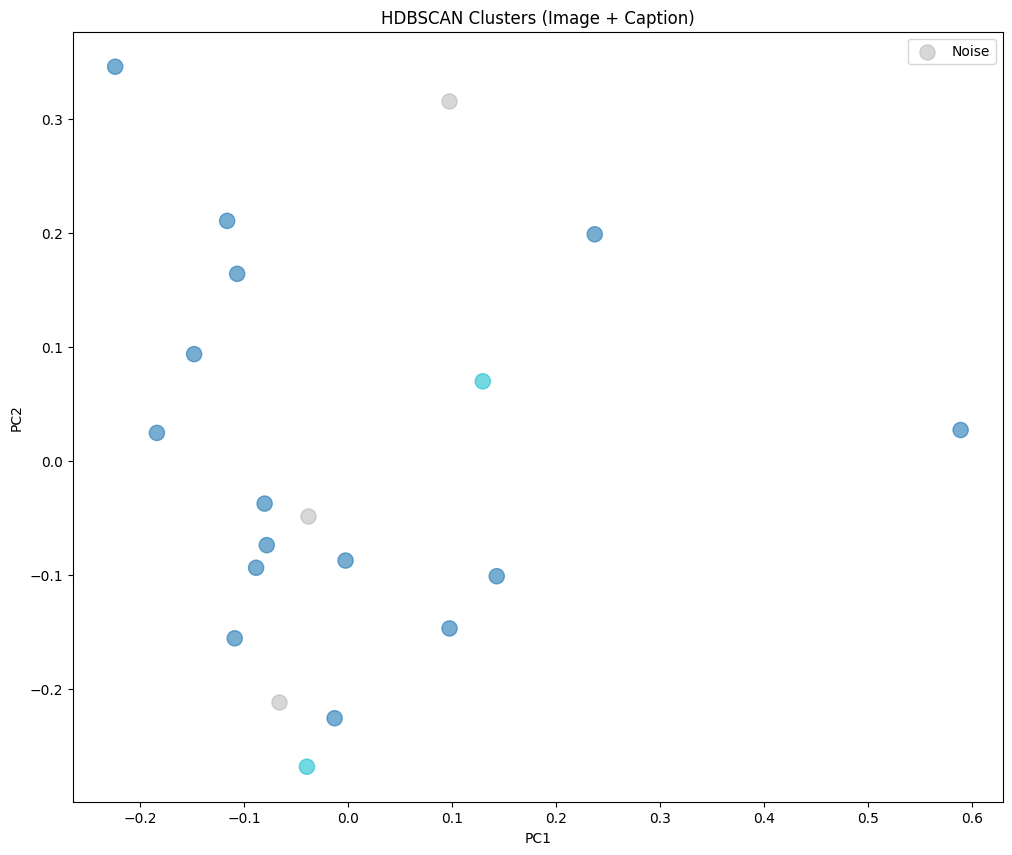

In [21]:
# --- HDBSCAN visualization with thumbnails (PCA 2D) ---

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

if "combined_embeddings" not in globals() or len(combined_embeddings) == 0:
    raise ValueError("combined_embeddings is empty. Run embedding generation first.")

if "embeddings_2d" not in globals() or len(embeddings_2d) != len(combined_embeddings):
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(combined_embeddings)

if "hdb_labels" not in globals() or len(hdb_labels) != len(combined_embeddings):
    try:
        import hdbscan
    except ImportError as exc:
        raise ImportError("hdbscan is required. Run the HDBSCAN setup cell first.") from exc

    # Refit labels to keep them synchronized with current embedding count.
    hdb = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1, metric="euclidean")
    hdb_labels = hdb.fit_predict(combined_embeddings)
    print("Refit HDBSCAN labels to match current embeddings.")

plt.figure(figsize=(12, 10))
ax = plt.gca()

noise_mask = (hdb_labels == -1)
cluster_mask = ~noise_mask

if noise_mask.any():
    ax.scatter(
        embeddings_2d[noise_mask, 0],
        embeddings_2d[noise_mask, 1],
        c="#B0B0B0",
        s=120,
        alpha=0.5,
        label="Noise"
    )

if cluster_mask.any():
    ax.scatter(
        embeddings_2d[cluster_mask, 0],
        embeddings_2d[cluster_mask, 1],
        c=hdb_labels[cluster_mask],
        cmap="tab10",
        s=120,
        alpha=0.6
    )

for i, row in df.iloc[:len(embeddings_2d)].iterrows():
    try:
        img = Image.open(row['photo/video_page_url'])
        img.thumbnail((80, 80))
        imagebox = OffsetImage(img, zoom=1)
        ab = AnnotationBbox(
            imagebox,
            (embeddings_2d[i][0], embeddings_2d[i][1]),
            frameon=False
        )
        ax.add_artist(ab)
        caption = str(row['caption'])[:40] + "..."
        ax.text(
            embeddings_2d[i][0],
            embeddings_2d[i][1],
            caption,
            fontsize=8,
            ha='center',
            va='top'
        )
    except Exception:
        continue

plt.title("HDBSCAN Clusters (Image + Caption)")
plt.xlabel("PC1")
plt.ylabel("PC2")
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(loc="best")
plt.show()

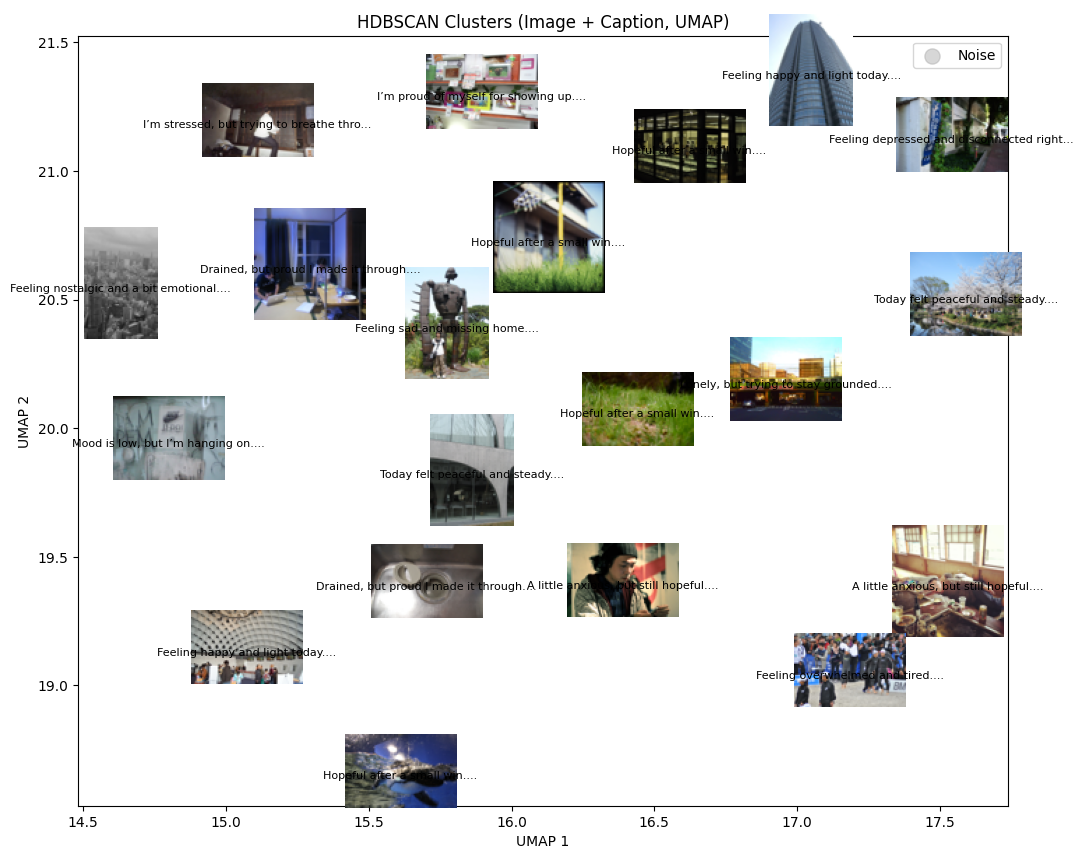

In [22]:
# --- HDBSCAN visualization with thumbnails (UMAP) ---

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

if "combined_embeddings" not in globals() or len(combined_embeddings) == 0:
    raise ValueError("combined_embeddings is empty. Run embedding generation first.")

try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError("umap-learn is required. Install it with: pip install umap-learn") from exc

if "embeddings_umap_2d" not in globals() or len(embeddings_umap_2d) != len(combined_embeddings):
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=42
    )
    embeddings_umap_2d = reducer.fit_transform(combined_embeddings)

if "hdb_labels" not in globals() or len(hdb_labels) != len(combined_embeddings):
    try:
        import hdbscan
    except ImportError as exc:
        raise ImportError("hdbscan is required. Run the HDBSCAN setup cell first.") from exc

    # Refit labels to keep them synchronized with current embedding count.
    hdb = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1, metric="euclidean")
    hdb_labels = hdb.fit_predict(combined_embeddings)
    print("Refit HDBSCAN labels to match current embeddings.")

plt.figure(figsize=(12, 10))
ax = plt.gca()

noise_mask = (hdb_labels == -1)
cluster_mask = ~noise_mask

if noise_mask.any():
    ax.scatter(
        embeddings_umap_2d[noise_mask, 0],
        embeddings_umap_2d[noise_mask, 1],
        c="#B0B0B0",
        s=120,
        alpha=0.5,
        label="Noise"
    )

if cluster_mask.any():
    ax.scatter(
        embeddings_umap_2d[cluster_mask, 0],
        embeddings_umap_2d[cluster_mask, 1],
        c=hdb_labels[cluster_mask],
        cmap="tab10",
        s=120,
        alpha=0.6
    )

for i, (_, row) in enumerate(df.iloc[:len(embeddings_umap_2d)].iterrows()):
    try:
        img = Image.open(row['photo/video_page_url'])
        img.thumbnail((80, 80))
        imagebox = OffsetImage(img, zoom=1)
        ab = AnnotationBbox(
            imagebox,
            (embeddings_umap_2d[i][0], embeddings_umap_2d[i][1]),
            frameon=False
        )
        ax.add_artist(ab)
        caption = str(row['caption'])[:40] + "..."
        ax.text(
            embeddings_umap_2d[i][0],
            embeddings_umap_2d[i][1],
            caption,
            fontsize=8,
            ha='center',
            va='top'
        )
    except Exception:
        continue

plt.title("HDBSCAN Clusters (Image + Caption, UMAP)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(loc="best")
plt.show()

In [23]:
# --- Comparison analysis (KMeans vs HDBSCAN) ---

from sklearn.metrics import silhouette_score

summary = {}

if "combined_embeddings" not in globals() or len(combined_embeddings) == 0:
    raise ValueError("combined_embeddings is empty. Run embedding generation first.")

# Keep KMeans labels in sync with current embedding count.
if "clusters" not in globals() or len(clusters) != len(combined_embeddings):
    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(combined_embeddings)
    print("Refit KMeans labels to match current embeddings.")

# Keep HDBSCAN labels in sync with current embedding count.
if "hdb_labels" not in globals() or len(hdb_labels) != len(combined_embeddings):
    try:
        import hdbscan
    except ImportError as exc:
        raise ImportError("hdbscan is required. Run the HDBSCAN setup cell first.") from exc
    hdb = hdbscan.HDBSCAN(min_cluster_size=2, min_samples=1, metric="euclidean")
    hdb_labels = hdb.fit_predict(combined_embeddings)
    print("Refit HDBSCAN labels to match current embeddings.")

# KMeans metrics
if len(np.unique(clusters)) > 1:
    summary["kmeans_silhouette"] = float(silhouette_score(combined_embeddings, clusters))
else:
    summary["kmeans_silhouette"] = None
summary["kmeans_num_clusters"] = int(len(np.unique(clusters)))

# HDBSCAN metrics (exclude noise)
noise_mask = (hdb_labels == -1)
cluster_mask = ~noise_mask
hdb_unique = np.unique(hdb_labels[cluster_mask]) if cluster_mask.any() else []
if cluster_mask.any() and len(hdb_unique) > 1:
    summary["hdbscan_silhouette"] = float(
        silhouette_score(combined_embeddings[cluster_mask], hdb_labels[cluster_mask])
    )
else:
    summary["hdbscan_silhouette"] = None
summary["hdbscan_num_clusters"] = int(len(hdb_unique))
summary["hdbscan_noise_ratio"] = float(noise_mask.mean())

print("=== Quantitative Summary ===")
for k, v in summary.items():
    print(f"{k}: {v}")

print("\n=== Interpretation ===")
if summary["kmeans_silhouette"] is None and summary["hdbscan_silhouette"] is None:
    print("Not enough clustered structure to compute silhouettes. Increase sample size or adjust clustering params.")
else:
    k_sil = summary["kmeans_silhouette"]
    h_sil = summary["hdbscan_silhouette"]
    h_noise = summary.get("hdbscan_noise_ratio", None)

    if h_sil is not None and (k_sil is None or h_sil > k_sil + 0.02):
        print("HDBSCAN performs better based on higher silhouette and adaptive cluster shapes.")
        if h_noise is not None and h_noise > 0.3:
            print("Note: HDBSCAN marked many points as noise; inspect those outliers for low-quality or unique memories.")
    elif k_sil is not None and (h_sil is None or k_sil >= h_sil - 0.02):
        print("KMeans performs comparably or better on this sample; clusters appear compact in PCA space.")
        if h_noise is not None and h_noise > 0.3:
            print("HDBSCAN noise ratio is high; KMeans may be more stable for this small dataset.")

    print("")
    print("Qualitative checks:")
    print("- Are clusters semantically coherent based on captions?")
    print("- Do thumbnails within a cluster share visual themes?")
    print("- Are noisy HDBSCAN points genuinely unique or just low-quality data?")
    print("- Try varying HDBSCAN min_cluster_size/min_samples and KMeans k to test stability.")

=== Quantitative Summary ===
kmeans_silhouette: 0.020023698967691746
kmeans_num_clusters: 3
hdbscan_silhouette: 0.030517397203947437
hdbscan_num_clusters: 2
hdbscan_noise_ratio: 0.15

=== Interpretation ===
KMeans performs comparably or better on this sample; clusters appear compact in PCA space.

Qualitative checks:
- Are clusters semantically coherent based on captions?
- Do thumbnails within a cluster share visual themes?
- Are noisy HDBSCAN points genuinely unique or just low-quality data?
- Try varying HDBSCAN min_cluster_size/min_samples and KMeans k to test stability.


## Late Fusion Experiment (Separate Image and Text Embeddings)

- Build image and text embeddings separately with Gemini.
- Create two similarity matrices: image-only and text-only.
- Fuse both matrices using adjustable weights.
- Run PCA + HDBSCAN and UMAP + HDBSCAN on the fused representation with thumbnail visualizations.

In [24]:
# --- Late fusion setup: separate image and text embedding extraction ---

late_fusion_model = "models/gemini-embedding-2-preview"

def get_image_embedding_gemini(image_path):
    try:
        img = Image.open(image_path)
        result = client.models.embed_content(
            model=late_fusion_model,
            contents=[img],
        )
        return np.array(result.embeddings[0].values)
    except Exception as e:
        print(f"[image] Skipping {image_path}: {e}")
        return None

def get_text_embedding_gemini(text):
    try:
        result = client.models.embed_content(
            model=late_fusion_model,
            contents=[str(text)],
        )
        return np.array(result.embeddings[0].values)
    except Exception as e:
        print(f"[text] Skipping caption: {e}")
        return None

In [25]:
# --- Generate separate embeddings for late fusion ---

late_fusion_rows = []
image_embeddings = []
text_embeddings = []

print("Generating separate image and text embeddings for late fusion...")

for idx, row in df.iterrows():
    img_path = row["photo/video_page_url"]
    caption = row["caption"]

    img_emb = get_image_embedding_gemini(img_path)
    txt_emb = get_text_embedding_gemini(caption)

    if img_emb is None or txt_emb is None:
        continue

    late_fusion_rows.append(
        {
            "original_index": idx,
            "photo/video_page_url": img_path,
            "caption": caption,
        }
    )
    image_embeddings.append(img_emb)
    text_embeddings.append(txt_emb)

image_embeddings = np.array(image_embeddings)
text_embeddings = np.array(text_embeddings)
late_fusion_df = pd.DataFrame(late_fusion_rows)

print(f"Valid rows for late fusion: {len(late_fusion_df)}")
print(f"Image embedding shape: {image_embeddings.shape}")
print(f"Text embedding shape: {text_embeddings.shape}")

Generating separate image and text embeddings for late fusion...
Valid rows for late fusion: 20
Image embedding shape: (20, 3072)
Text embedding shape: (20, 3072)


Image similarity matrix shape: (20, 20)
Text similarity matrix shape: (20, 20)


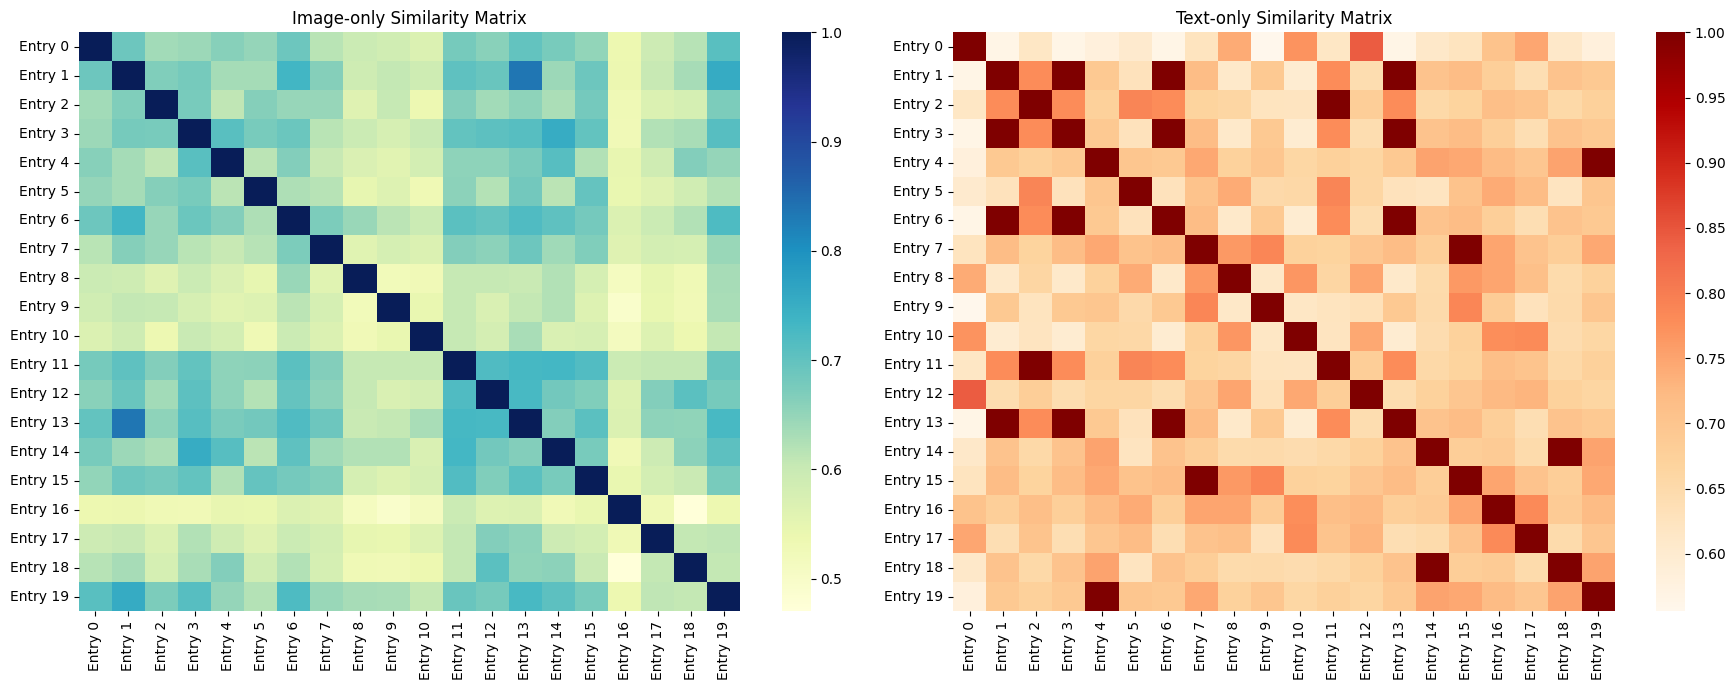

In [26]:
# --- Build separate similarity matrices (image vs text) ---

if len(image_embeddings) == 0 or len(text_embeddings) == 0:
    raise ValueError("Late-fusion embeddings are empty. Run previous cell first.")

image_similarity_matrix = cosine_similarity(image_embeddings, image_embeddings)
text_similarity_matrix = cosine_similarity(text_embeddings, text_embeddings)

print("Image similarity matrix shape:", image_similarity_matrix.shape)
print("Text similarity matrix shape:", text_similarity_matrix.shape)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    image_similarity_matrix,
    cmap="YlGnBu",
    ax=axes[0],
    xticklabels=[f"Entry {i}" for i in range(len(image_similarity_matrix))],
    yticklabels=[f"Entry {i}" for i in range(len(image_similarity_matrix))],
)
axes[0].set_title("Image-only Similarity Matrix")

sns.heatmap(
    text_similarity_matrix,
    cmap="OrRd",
    ax=axes[1],
    xticklabels=[f"Entry {i}" for i in range(len(text_similarity_matrix))],
    yticklabels=[f"Entry {i}" for i in range(len(text_similarity_matrix))],
)
axes[1].set_title("Text-only Similarity Matrix")

plt.tight_layout()
plt.show()

## Changable weights

In [27]:
# --- Weighted late fusion of similarity matrices ---

image_weight = 0.2
text_weight = 0.8

if image_weight < 0 or text_weight < 0:
    raise ValueError("Weights must be non-negative.")

weight_sum = image_weight + text_weight
if weight_sum == 0:
    raise ValueError("At least one weight must be positive.")

image_weight /= weight_sum
text_weight /= weight_sum

fused_similarity_matrix = (
    image_weight * image_similarity_matrix
    + text_weight * text_similarity_matrix
)

# Each row is a fused similarity profile used as features for clustering.
fused_features = fused_similarity_matrix.copy()

print(f"Using image_weight={image_weight:.3f}, text_weight={text_weight:.3f}")
print("Fused similarity matrix shape:", fused_similarity_matrix.shape)

Using image_weight=0.200, text_weight=0.800
Fused similarity matrix shape: (20, 20)


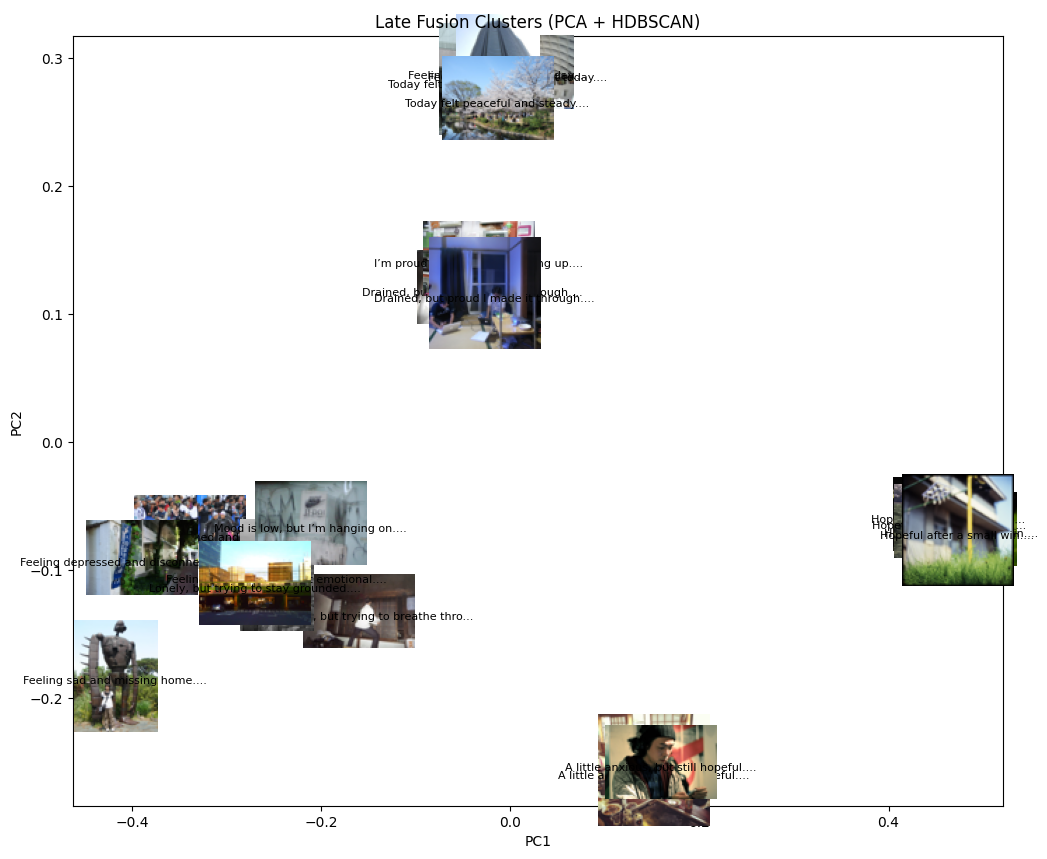

In [28]:
# --- Late fusion: PCA + HDBSCAN visualization with thumbnails ---

from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

try:
    import hdbscan
except ImportError as exc:
    raise ImportError("hdbscan is required. Install it with: pip install hdbscan") from exc

if "fused_features" not in globals() or len(fused_features) == 0:
    raise ValueError("fused_features is empty. Run the late-fusion cells first.")

pca_late_2d = PCA(n_components=2).fit_transform(fused_features)
hdb_late_pca_labels = hdbscan.HDBSCAN(
    min_cluster_size=2,
    min_samples=1,
    metric="euclidean",
).fit_predict(fused_features)

plt.figure(figsize=(12, 10))
ax = plt.gca()

noise_mask = (hdb_late_pca_labels == -1)
cluster_mask = np.logical_not(noise_mask)

if noise_mask.any():
    ax.scatter(
        pca_late_2d[noise_mask, 0],
        pca_late_2d[noise_mask, 1],
        c="#B0B0B0",
        s=120,
        alpha=0.5,
        label="Noise",
    )

if cluster_mask.any():
    ax.scatter(
        pca_late_2d[cluster_mask, 0],
        pca_late_2d[cluster_mask, 1],
        c=hdb_late_pca_labels[cluster_mask],
        cmap="tab10",
        s=120,
        alpha=0.6,
    )

for i, (_, row) in enumerate(late_fusion_df.iterrows()):
    try:
        img = Image.open(row["photo/video_page_url"])
        img.thumbnail((80, 80))
        imagebox = OffsetImage(img, zoom=1)
        ab = AnnotationBbox(
            imagebox,
            (pca_late_2d[i][0], pca_late_2d[i][1]),
            frameon=False,
        )
        ax.add_artist(ab)
        caption = str(row["caption"])[:40] + "..."
        ax.text(
            pca_late_2d[i][0],
            pca_late_2d[i][1],
            caption,
            fontsize=8,
            ha="center",
            va="top",
        )
    except Exception:
        continue

plt.title("Late Fusion Clusters (PCA + HDBSCAN)")
plt.xlabel("PC1")
plt.ylabel("PC2")
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(loc="best")
plt.show()

c:\Users\ANISH\OneDrive\Desktop\osC\DREAMS\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


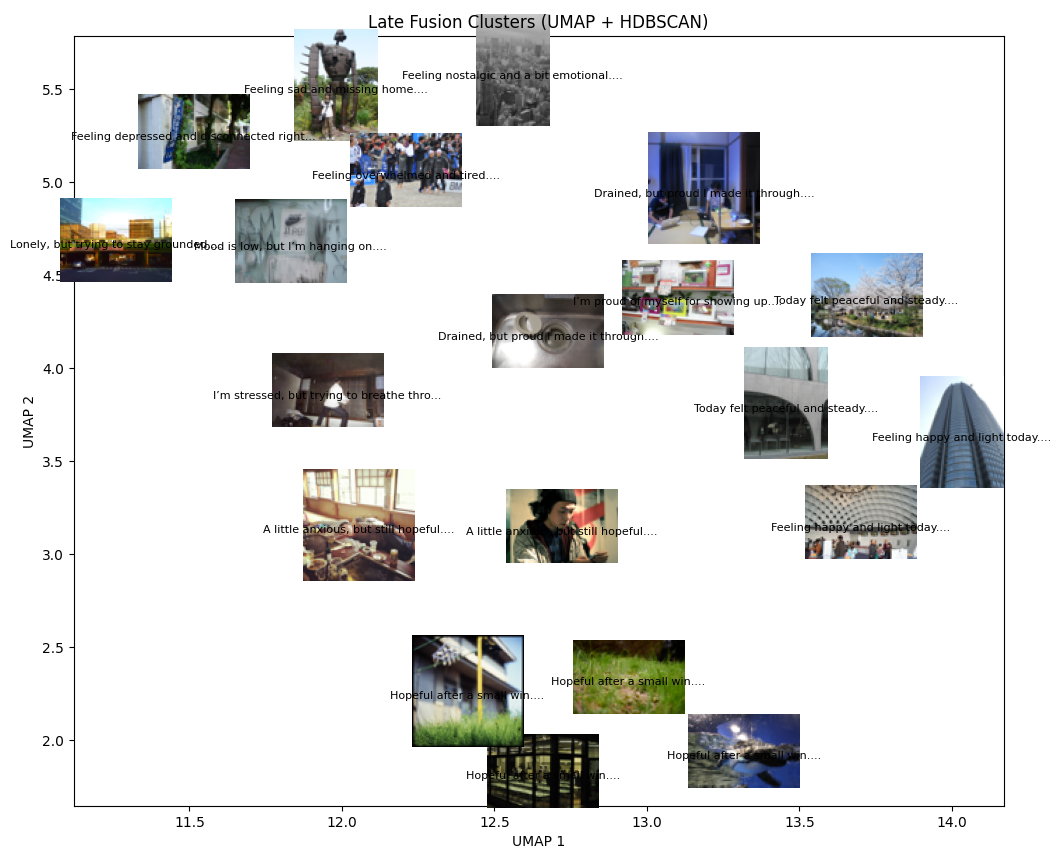

In [29]:
# --- Late fusion: UMAP + HDBSCAN visualization with thumbnails ---

try:
    import umap.umap_ as umap
except ImportError as exc:
    raise ImportError("umap-learn is required. Install it with: pip install umap-learn") from exc

try:
    import hdbscan
except ImportError as exc:
    raise ImportError("hdbscan is required. Install it with: pip install hdbscan") from exc

if "fused_features" not in globals() or len(fused_features) == 0:
    raise ValueError("fused_features is empty. Run the late-fusion cells first.")

umap_late_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
).fit_transform(fused_features)

hdb_late_umap_labels = hdbscan.HDBSCAN(
    min_cluster_size=2,
    min_samples=1,
    metric="euclidean",
).fit_predict(fused_features)

plt.figure(figsize=(12, 10))
ax = plt.gca()

noise_mask = (hdb_late_umap_labels == -1)
cluster_mask = np.logical_not(noise_mask)

if noise_mask.any():
    ax.scatter(
        umap_late_2d[noise_mask, 0],
        umap_late_2d[noise_mask, 1],
        c="#B0B0B0",
        s=120,
        alpha=0.5,
        label="Noise",
    )

if cluster_mask.any():
    ax.scatter(
        umap_late_2d[cluster_mask, 0],
        umap_late_2d[cluster_mask, 1],
        c=hdb_late_umap_labels[cluster_mask],
        cmap="tab10",
        s=120,
        alpha=0.6,
    )

for i, (_, row) in enumerate(late_fusion_df.iterrows()):
    try:
        img = Image.open(row["photo/video_page_url"])
        img.thumbnail((80, 80))
        imagebox = OffsetImage(img, zoom=1)
        ab = AnnotationBbox(
            imagebox,
            (umap_late_2d[i][0], umap_late_2d[i][1]),
            frameon=False,
        )
        ax.add_artist(ab)
        caption = str(row["caption"])[:40] + "..."
        ax.text(
            umap_late_2d[i][0],
            umap_late_2d[i][1],
            caption,
            fontsize=8,
            ha="center",
            va="top",
        )
    except Exception:
        continue

plt.title("Late Fusion Clusters (UMAP + HDBSCAN)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
handles, labels = ax.get_legend_handles_labels()
if handles:
    plt.legend(loc="best")
plt.show()